# load packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from connectome_interpreter import *
import scipy as sp

In [2]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
meta = pd.read_csv('../data/fafb_all_neuron/fafb_all_neuron_meta.csv', index_col=0)
root_to_type = dict(zip(meta.root_id, meta.cell_type))
idx_to_type = dict(zip(meta.idx, meta.cell_type))
idx_to_root = dict(zip(meta.idx, meta.root_id))
type_to_sign = dict(zip(meta.cell_type, meta.sign))
meta

C:\Users\44745\AppData\Local\Temp\ipykernel_169764\3378544010.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv('../data/fafb_all_neuron/fafb_all_neuron_meta.csv', index_col=0)


,root_id,cell_type,side,top_nt,super_class,cell_class,cell_sub_class,ito_lee_hemilineage,hartenstein_hemilineage,idx,sign,coords
0,720575940628857210,PS180,left,acetylcholine,central,NaN,NaN,SMPpv2_ventral,CP1_ventral,90900,1,NaN
1,720575940626838909,CB0924,right,acetylcholine,central,NaN,NaN,VLPl2_medial,BLAv2_medial,78909,1,NaN
2,720575940626046919,AVLP429,right,acetylcholine,central,NaN,NaN,putative_primary,NaN,74855,1,NaN
3,720575940630311383,AVLP151,right,acetylcholine,central,NaN,NaN,putative_primary,putative_primary,98344,1,NaN
4,720575940633370649,LC27,right,acetylcholine,visual_projection,NaN,NaN,NaN,NaN,112637,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
139237,720575940618571494,MLt7,right,acetylcholine,optic,ME>LO,NaN,NaN,NaN,35797,1,NaN
139238,720575940633170572,Li02,right,acetylcholine,optic,LO,NaN,NaN,NaN,111842,1,NaN
139239,720575940650339961,Li02,right,acetylcholine,optic,LO,NaN,NaN,NaN,137234,1,NaN
139240,720575940619997854,MTe51,left,acetylcholine,optic,ME>LO,NaN,NaN,NaN,41495,1,NaN


In [4]:
inprop = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_inprop_all_neuron.npz")
ad_inprop = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_ad_inprop_all_neuron.npz")
inprop_e_only = modify_coo_matrix(inprop, meta.idx[meta.top_nt != 'acetylcholine'], 
                                  meta.idx, 0, re_normalize=False)
ad_inprop_e_only = modify_coo_matrix(ad_inprop, meta.idx[meta.top_nt != 'acetylcholine'], 
                                     meta.idx, 0, re_normalize=False)

Updating matrix...
Updating matrix...


In [5]:
result = pd.read_csv("recurrence_results.csv")
result

,pre,post,plen,connected,effconn,effconn_e,effconn_ad,effconn_ad_e
0,CB1729,CB1729,1,True,0.002488,0.002488,0.000000,0.000000e+00
1,CB1729,CB1729,2,True,0.000484,0.000444,0.000064,4.809998e-05
2,CB1729,CB1729,3,True,0.000078,0.000039,0.000024,8.403953e-06
3,CB1729,CB1729,4,True,0.000054,0.000012,0.000014,2.049652e-06
4,CB1729,CB1729,5,True,0.000038,0.000005,0.000009,7.338927e-07
...,...,...,...,...,...,...,...,...
44025,PS053,PS053,1,False,0.000000,0.000000,0.000000,0.000000e+00
44026,PS053,PS053,2,True,0.004132,0.002492,0.004068,4.068170e-03
44027,PS053,PS053,3,True,0.001300,0.000203,0.000425,2.365099e-05
44028,PS053,PS053,4,True,0.000805,0.000061,0.000167,2.611533e-05


In [6]:
result.plen.value_counts()

plen
1    8806
2    8806
3    8806
4    8806
5    8806
Name: count, dtype: int64

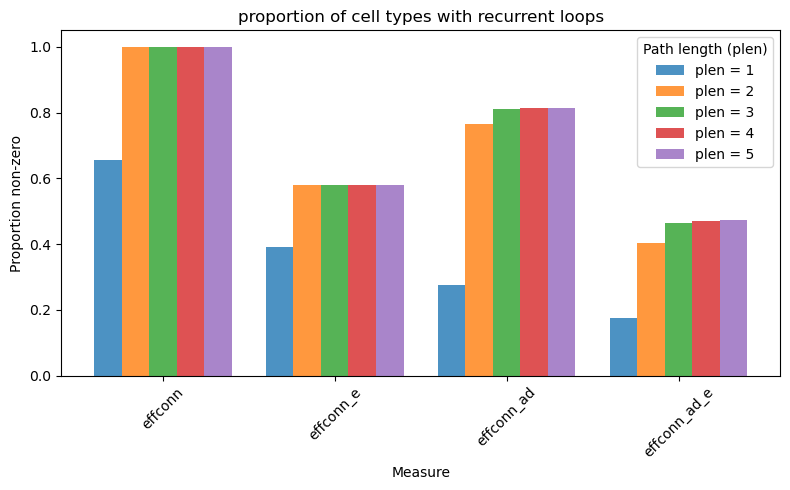

In [7]:
cols = ["effconn", "effconn_e", "effconn_ad", "effconn_ad_e"]

# proportion non-zero per plen
prop = (
    result
    .groupby("plen")[cols]
    .apply(lambda df: (df != 0).sum() / len(df))
    .reset_index()
    .melt(id_vars="plen", value_vars=cols,
          var_name="measure", value_name="prop_nonzero")
)

measure_order = cols
prop["measure"] = pd.Categorical(
    prop["measure"], categories=measure_order, ordered=True
)

plens = sorted(prop["plen"].unique())
n_plen = len(plens)

x = np.arange(len(measure_order))
width = 0.8 / n_plen

plt.figure(figsize=(8, 5))

for i, plen in enumerate(plens):
    sub = (
        prop[prop["plen"] == plen]
        .set_index("measure")
        .loc[measure_order]
        .reset_index()
    )
    plt.bar(
        x + (i - (n_plen - 1) / 2) * width,
        sub["prop_nonzero"].values,
        width=width,
        alpha=0.8,
        label=f"plen = {plen}",
    )

plt.xticks(x, measure_order, rotation=45)
plt.ylabel("Proportion non-zero")
plt.xlabel("Measure")
plt.legend(title="Path length (plen)")
plt.title('proportion of cell types with recurrent loops')
plt.tight_layout()
plt.show()


In [8]:
across_plen = result.groupby(['pre','connected'])[['effconn','effconn_e', 'effconn_ad', 'effconn_ad_e']].sum().reset_index()
display_df(across_plen.drop('connected', axis=1).sort_values('effconn_e', ascending=False).head(30).set_index('pre'))

,effconn,effconn_e,effconn_ad,effconn_ad_e
pre,,,,
HBeyelet,1.535427,1.502883,0.000000,0.000000
KCab,1.597021,1.456483,0.025731,0.000014
BM_InOm,1.792008,1.284599,0.000000,0.000000
KCapbp-m,1.333224,1.257201,0.020025,0.000100
SA_VTV_4,1.856953,1.253368,0.000000,0.000000
KCapbp-ap1,1.271296,1.214715,0.008089,0.000242
KCg-m,1.352169,1.170456,0.045243,0.001678
KCab-p,1.163843,1.145823,0.006202,0.000011
KCapbp-ap2,1.092980,1.026795,0.014602,0.000104


In [9]:
# single cell 
sc = pd.read_csv("sc_recurrence_results.csv")
sc['pre_type'] = sc.pre.map(root_to_type)
sc['post_type'] = sc.post.map(root_to_type)
sc['plen'] = sc['plen'].astype(str)
sc

,pre,post,plen,effconn,effconn_e,effconn_i,e_effconn,ad_effconn,ad_effconn_e,ad_effconn_i,ad_e_effconn,pre_type,post_type
0,720575940617986345,720575940617986345,2,0.002574,0.001822,0.000753,0.001511,0.0,0.0,0.0,0.0,HRN_VP1d,HRN_VP1d
1,720575940617986345,720575940617986345,3,0.000980,0.000627,0.000353,0.000416,0.0,0.0,0.0,0.0,HRN_VP1d,HRN_VP1d
2,720575940617986345,720575940617986345,4,0.000675,0.000407,0.000268,0.000190,0.0,0.0,0.0,0.0,HRN_VP1d,HRN_VP1d
3,720575940617986345,720575940617986345,5,0.000530,0.000295,0.000235,0.000093,0.0,0.0,0.0,0.0,HRN_VP1d,HRN_VP1d
4,720575940617986345,720575940617986345,6,0.000451,0.000237,0.000214,0.000048,0.0,0.0,0.0,0.0,HRN_VP1d,HRN_VP1d
...,...,...,...,...,...,...,...,...,...,...,...,...,...
687650,720575940623616611,720575940623616611,2,0.031693,0.013694,0.017999,0.013694,0.0,0.0,0.0,0.0,R1-6,R1-6
687651,720575940623616611,720575940623616611,3,0.003196,0.002929,0.000267,0.002845,0.0,0.0,0.0,0.0,R1-6,R1-6
687652,720575940623616611,720575940623616611,4,0.006620,0.004859,0.001760,0.001301,0.0,0.0,0.0,0.0,R1-6,R1-6
687653,720575940623616611,720575940623616611,5,0.002448,0.001586,0.000862,0.000636,0.0,0.0,0.0,0.0,R1-6,R1-6


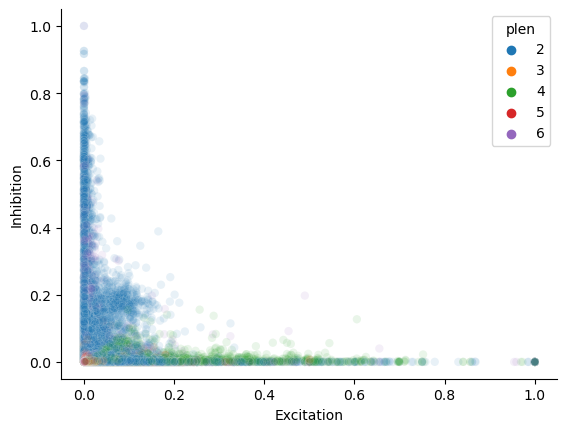

In [10]:
sns.scatterplot(sc, 
x = 'effconn_e',
y = 'effconn_i',
hue = 'plen',
alpha=0.1)

# plt.xscale("symlog", linthresh=1e-3)
# plt.yscale("symlog", linthresh=1e-3)
plt.xlabel("Excitation")
plt.ylabel("Inhibition")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

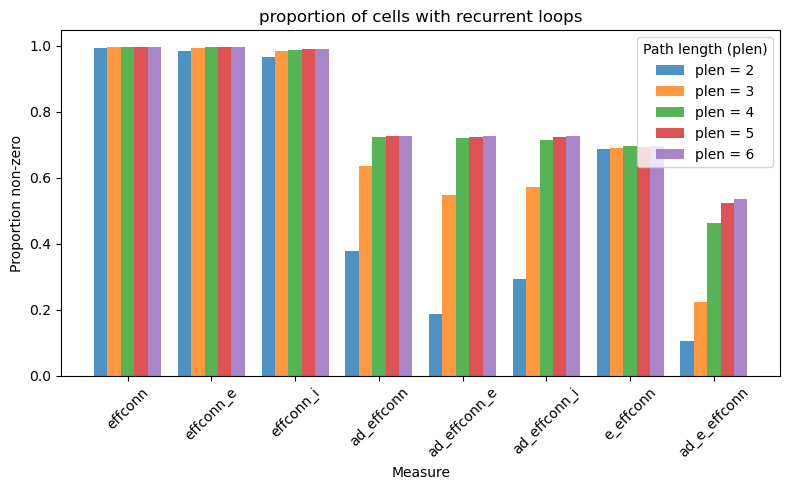

In [11]:
cols = ["effconn", 'effconn_e', 'effconn_i', "ad_effconn", 'ad_effconn_e','ad_effconn_i', "e_effconn", "ad_e_effconn"]

# proportion non-zero per plen
prop = (
    sc
    .groupby("plen")[cols]
    .apply(lambda df: (df != 0).sum() / len(df))
    .reset_index()
    .melt(id_vars="plen", value_vars=cols,
          var_name="measure", value_name="prop_nonzero")
)

measure_order = cols
prop["measure"] = pd.Categorical(
    prop["measure"], categories=measure_order, ordered=True
)

plens = sorted(prop["plen"].unique())
n_plen = len(plens)

x = np.arange(len(measure_order))
width = 0.8 / n_plen

plt.figure(figsize=(8, 5))

for i, plen in enumerate(plens):
    sub = (
        prop[prop["plen"] == plen]
        .set_index("measure")
        .loc[measure_order]
        .reset_index()
    )
    plt.bar(
        x + (i - (n_plen - 1) / 2) * width,
        sub["prop_nonzero"].values,
        width=width,
        alpha=0.8,
        label=f"plen = {plen}",
    )

plt.xticks(x, measure_order, rotation=45)
plt.ylabel("Proportion non-zero")
plt.xlabel("Measure")
plt.legend(title="Path length (plen)")
plt.title('proportion of cells with recurrent loops')
plt.tight_layout()
plt.show()


In [12]:
sc_long = sc.melt(id_vars=["pre", "post", "pre_type", "post_type", "plen"],
                  value_vars=cols,
                  var_name="measure", value_name="effective_connectivity")
sc_long['effconn_sqrt'] = np.sqrt(sc_long['effective_connectivity'])
sc_long['plen'] = sc_long['plen'].astype(str)
sc_long

,pre,post,pre_type,post_type,plen,measure,effective_connectivity,effconn_sqrt
0,720575940617986345,720575940617986345,HRN_VP1d,HRN_VP1d,2,effconn,0.002574,0.050739
1,720575940617986345,720575940617986345,HRN_VP1d,HRN_VP1d,3,effconn,0.000980,0.031299
2,720575940617986345,720575940617986345,HRN_VP1d,HRN_VP1d,4,effconn,0.000675,0.025975
3,720575940617986345,720575940617986345,HRN_VP1d,HRN_VP1d,5,effconn,0.000530,0.023022
4,720575940617986345,720575940617986345,HRN_VP1d,HRN_VP1d,6,effconn,0.000451,0.021238
...,...,...,...,...,...,...,...,...
5501235,720575940623616611,720575940623616611,R1-6,R1-6,2,ad_e_effconn,0.000000,0.000000
5501236,720575940623616611,720575940623616611,R1-6,R1-6,3,ad_e_effconn,0.000000,0.000000
5501237,720575940623616611,720575940623616611,R1-6,R1-6,4,ad_e_effconn,0.000000,0.000000
5501238,720575940623616611,720575940623616611,R1-6,R1-6,5,ad_e_effconn,0.000000,0.000000


c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


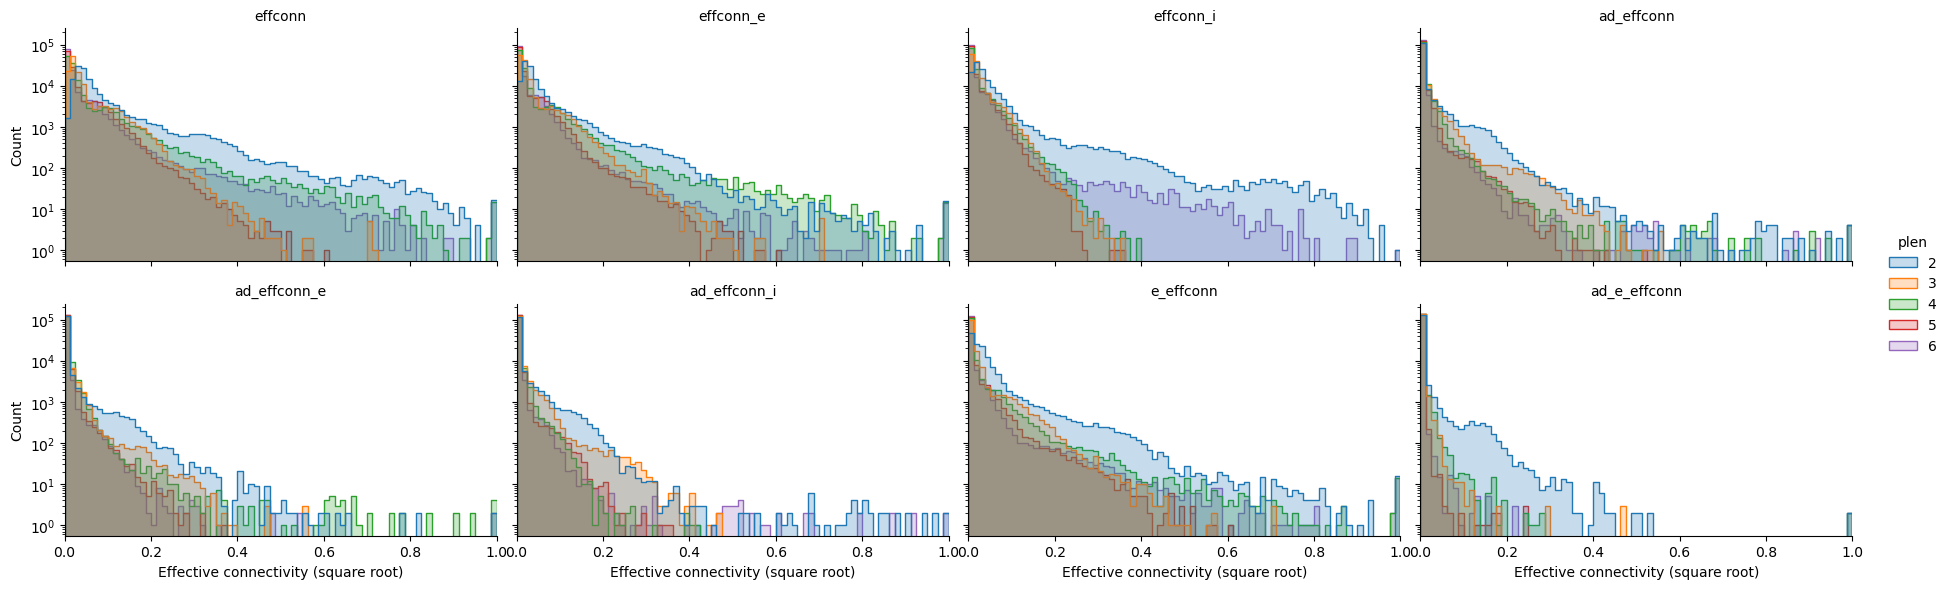

In [13]:
g = sns.displot(
    data=sc_long,
    x="effconn_sqrt",
    hue="plen",
    col="measure",
    col_wrap=4,              # change as needed
    kind="hist",
    element="step",
    stat="count",
    common_bins=True,
    bins=80,                 # tune to match your look
    height=3.0,
    aspect=1.6,
)

g.set_axis_labels("Effective connectivity (square root)", "Count")
g.set_titles(col_template="{col_name}")
g.set(yscale="log")

# make x-limits consistent (optional)
xmin = sc_long["effconn_sqrt"].min()
xmax = sc_long["effconn_sqrt"].max()
g.set(xlim=(xmin, xmax))

plt.show()


# connected components of generally self-excitatory

In [14]:
sc_across_plen = sc.groupby(['pre','pre_type'])[['effconn','effconn_e', 'effconn_i', 'ad_effconn', 'ad_effconn_e','ad_effconn_i', 'e_effconn', 'ad_e_effconn']].sum().reset_index()
sc_across_plen['effconn_diff'] = sc_across_plen['effconn_e'] - sc_across_plen['effconn_i']
sc_across_plen['ad_effconn_diff'] = sc_across_plen['ad_effconn_e'] - sc_across_plen['ad_effconn_i']
sc_across_plen

,pre,pre_type,effconn,effconn_e,effconn_i,ad_effconn,ad_effconn_e,ad_effconn_i,e_effconn,ad_e_effconn,effconn_diff,ad_effconn_diff
0,720575940596125868,T5c,0.001430,0.000548,0.000882,0.000115,0.000081,0.000033,0.000453,6.010477e-07,-0.000334,4.791717e-05
1,720575940597856265,Tm16,0.004620,0.001551,0.003069,0.000000,0.000000,0.000000,0.000697,0.000000e+00,-0.001518,0.000000e+00
2,720575940597944841,Tm7,0.002201,0.001138,0.001063,0.000005,0.000002,0.000003,0.000898,8.748257e-07,0.000074,-5.009492e-07
3,720575940598267657,TmY15,0.006104,0.001475,0.004629,0.000000,0.000000,0.000000,0.000000,0.000000e+00,-0.003154,0.000000e+00
4,720575940599333574,Tm1,0.013658,0.006340,0.007318,0.007599,0.000521,0.007078,0.004727,1.625358e-05,-0.000978,-6.556752e-03
...,...,...,...,...,...,...,...,...,...,...,...,...
137526,720575940661335681,CB0180,0.002489,0.000927,0.001562,0.000575,0.000244,0.000331,0.000000,0.000000e+00,-0.000634,-8.729747e-05
137527,720575940661336193,TmY3,0.003110,0.001859,0.001250,0.000277,0.000111,0.000166,0.001613,6.593132e-08,0.000609,-5.546962e-05
137528,720575940661337217,KCab-p,0.012763,0.012426,0.000337,0.000063,0.000008,0.000055,0.010189,2.038184e-07,0.012089,-4.763513e-05
137529,720575940661338497,CB0904,0.002414,0.001116,0.001298,0.000000,0.000000,0.000000,0.000645,0.000000e+00,-0.000182,0.000000e+00


In [15]:
sc_across_plen.groupby('pre_type').ad_effconn_diff.mean().reset_index().sort_values('ad_effconn_diff', ascending=False)

,pre_type,ad_effconn_diff
2708,CB0756,0.108589
7682,PFNv,0.033876
8014,PS215,0.032343
7921,PS083b,0.029211
7354,Lawf1,0.028899
...,...,...
1692,ATL001,-0.027294
6612,L5,-0.038078
9063,Sm39,-0.052827
466,720575940623049548,-0.065385


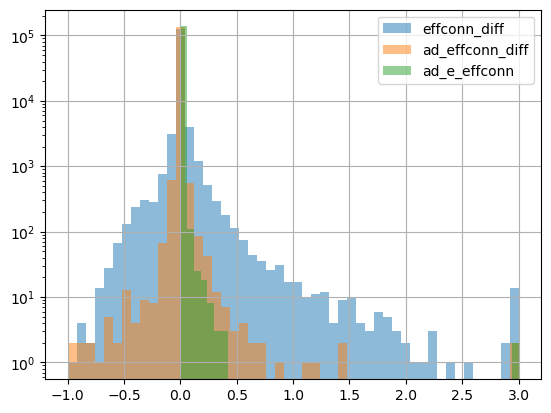

In [16]:
sc_across_plen.effconn_diff.hist(bins=50, alpha=0.5, label='effconn_diff')
sc_across_plen.ad_effconn_diff.hist(bins=50, alpha =0.5, label='ad_effconn_diff')
sc_across_plen.ad_e_effconn.hist(bins=50, alpha=0.5, label='ad_e_effconn')
plt.yscale('log')
plt.legend()

Text(0, 0.5, 'ad_effconn_diff')

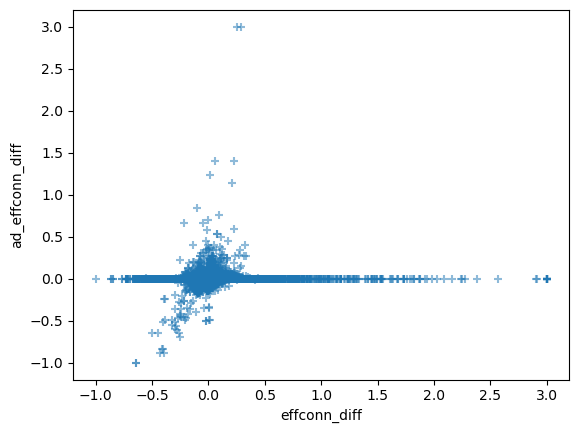

In [17]:
plt.scatter(sc_across_plen['effconn_diff'], sc_across_plen['ad_effconn_diff'], alpha=0.5, marker='+')
plt.xlabel('effconn_diff')
plt.ylabel('ad_effconn_diff')

In [18]:
excitatory = sc_across_plen[sc_across_plen.ad_e_effconn > 0.001]
conn = pd.DataFrame(
    {'pre': ad_inprop.row, 'post': ad_inprop.col, 'weight': ad_inprop.data}
)
conn['pre_root_id'] = conn['pre'].map(idx_to_root)
conn['post_root_id'] = conn['post'].map(idx_to_root)
# only get excitatory connections
conn = conn[conn['pre_root_id'].isin(excitatory['pre']) & conn['post_root_id'].isin(excitatory['pre'])]
conn

,pre,post,weight,pre_root_id,post_root_id
531,25,36951,0.021277,720575940600588204,720575940618858375
560,25,134742,0.014925,720575940600588204,720575940645468014
2290,73,98355,0.031915,720575940602618848,720575940630313035
3494,97,947,0.018182,720575940602917088,720575940604786889
3496,97,6623,0.007536,720575940602917088,720575940608918830
...,...,...,...,...,...
5708956,139061,59517,0.200000,720575940661273217,720575940623187670
5708957,139061,104825,0.333333,720575940661273217,720575940631538294
5708958,139061,110390,0.500000,720575940661273217,720575940632780857
5708959,139061,114996,0.200000,720575940661273217,720575940634195923


In [19]:
# get connected componets 
import networkx as nx
G = nx.from_pandas_edgelist(conn, source='pre_root_id', target='post_root_id', edge_attr='weight', create_using=nx.DiGraph)
components = list(nx.strongly_connected_components(G))
components = sorted(components, key=lambda x: len(x), reverse=True)

In [20]:
len(components)

1027

In [21]:
component_sizes = [len(c) for c in components]
sorted(component_sizes, reverse=True)[:10]

[1682, 926, 14, 12, 11, 10, 10, 9, 8, 8]

In [22]:
meta[meta.root_id.isin(components[0])].cell_type.value_counts()

cell_type
L2             415
T1             410
L3             402
Lawf1          216
Lawf2           48
Mi15            39
L5              24
L4              24
Dm2             16
Tm7             12
Sm02            10
Mi1              7
Tm3              6
Sm01             5
Tm2              5
Tm1              5
Tm4              5
MeTu3c           4
Tm5b             4
T2a              3
Tm27             3
T2               3
aMe10            3
aMe4             3
T3               2
TmY4             1
TmY20            1
MLt3             1
T4a              1
TmY9q__perp      1
TmY9q            1
aMe6a            1
aMe6b            1
Name: count, dtype: int64

# inspect paths of recurrent neurons

In [23]:
inidx = meta.idx[meta.cell_type == 'v2LN4']
conn_by_path_length(ad_inprop_e_only, inidx, inidx, 5, idx_to_type)

100%|██████████| 5/5 [00:08<00:00,  1.66s/it]


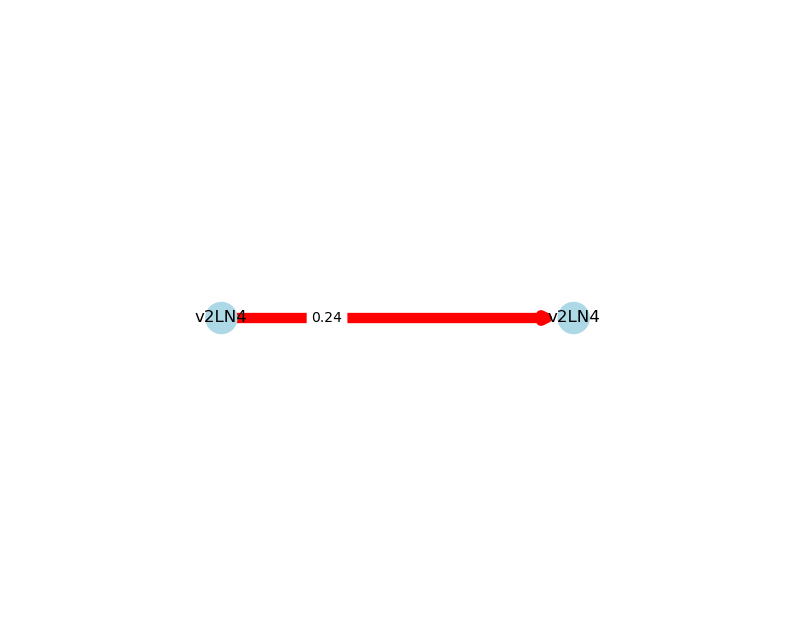

In [24]:
paths = find_paths_of_length(ad_inprop_e_only, inidx, inidx, 1)
paths = group_paths(paths, idx_to_type, idx_to_type)
paths = filter_paths(paths, 0.01)
plot_paths(paths, neuron_to_sign = type_to_sign)